In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'grouped'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'isolated'


df = pd.concat([df1, df2], ignore_index=True)

print(df.columns)



Index(['track_id', 'frame', 'instance_score', 'x_head', 'y_head', 'score_head',
       'x_body', 'y_body', 'score_body', 'x_tail',
       ...
       'is_stationary_large_bend', 'is_stationary_turn_related',
       'closest_node_node_other_id', 'closest_nodes',
       'closest_node_node_distance', 'head_nearest_id', 'closest_node_to_head',
       'head_distance', 'file', 'condition'],
      dtype='object', length=104)


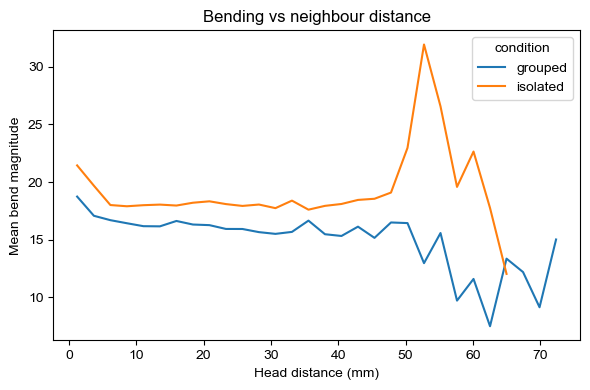

In [41]:
df_plot = df[
    (df["head_distance"].notna()) &
    (df["bend_magnitude"].notna())
].copy()

# bin distances
df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=30)

# get bin centres
df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid)

binned = (
    df_plot.groupby(["distance_mid", "condition"])["bend_magnitude"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="condition"
)

plt.ylabel("Mean bend magnitude")
plt.xlabel("Head distance (mm)")
plt.title("Bending vs neighbour distance")

plt.tight_layout()
plt.show()

In [ ]:
df_plot = df[
    (df["head_distance"].notna()) &
    (df["bend_magnitude"].notna())
].copy()

# bin distances in 0.5 mm steps
bin_width = 0.5
bin_min = np.floor(df_plot["head_distance"].min() / bin_width) * bin_width
bin_max = np.ceil(df_plot["head_distance"].max() / bin_width) * bin_width
bins = np.arange(bin_min, bin_max + bin_width, bin_width)
df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=bins, include_lowest=True)

# get bin centres
df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid)

binned = (
    df_plot.groupby(["file", "condition", "distance_mid"], observed=True)["bend_magnitude"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="condition",
    errorbar=("ci", 95), palette=PALETTE, hue_order=HUE_ORDER
)

plt.ylabel("Mean bend magnitude")
plt.xlabel("Head distance (mm)")
plt.title("Bending vs neighbour distance")
plt.xlim(0, 20)

plt.tight_layout()
plt.show()

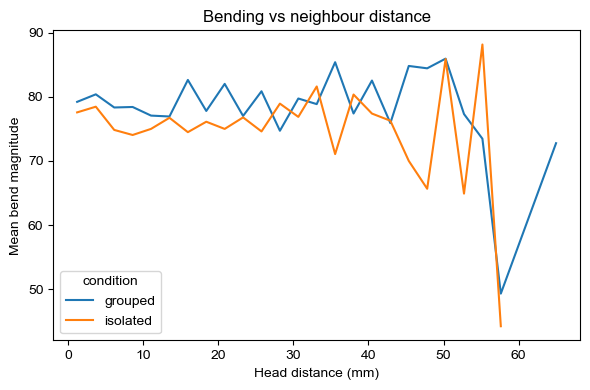

In [42]:
df_plot = df[
    (df["head_distance"].notna()) &
    (df["bend_magnitude"].notna())
].copy()

# bin distances
df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=30)

# get bin centres
df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid)


## only sharp turn !!
df_plot = df_plot[df_plot['behaviour'] == 'sharp_turn']

binned = (
    df_plot.groupby(["distance_mid", "condition"])["bend_magnitude"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="condition"
)

plt.ylabel("Mean bend magnitude")
plt.xlabel("Head distance (mm)")
plt.title("Bending vs neighbour distance")

plt.tight_layout()
plt.show()

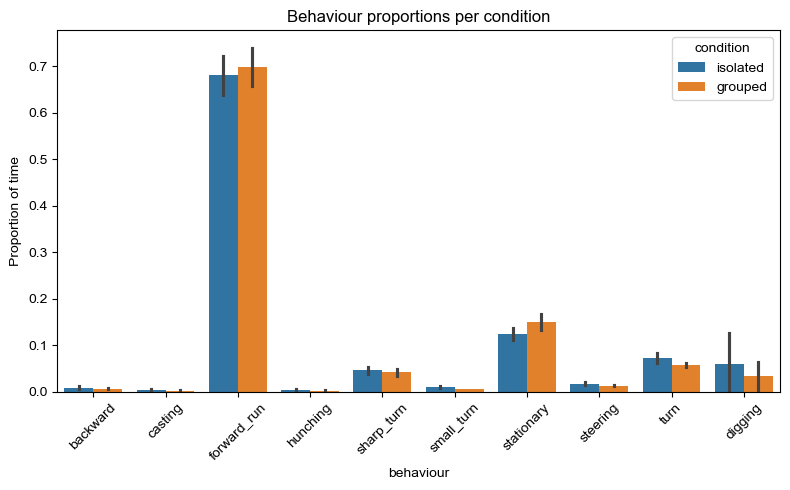

In [43]:
# total frames per video
total_frames = (
    df.groupby(["file"])
    .size()
    .reset_index(name="total_frames")
)

# frames per behaviour per video
behaviour_frames = (
    df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# merge + compute proportion
behaviour_prop = behaviour_frames.merge(total_frames, on="file")
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]


plt.figure(figsize=(8,5))

sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="condition",
    errorbar="sd"
)

plt.ylim(0,None)
plt.xticks(rotation=45)
plt.ylabel("Proportion of time")
plt.title("Behaviour proportions per condition")

plt.tight_layout()
plt.show()

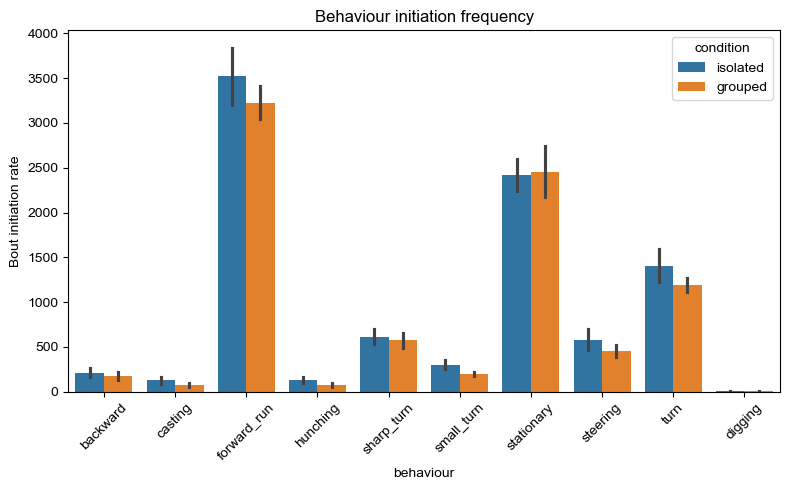

In [44]:
df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_41025/1805961386.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


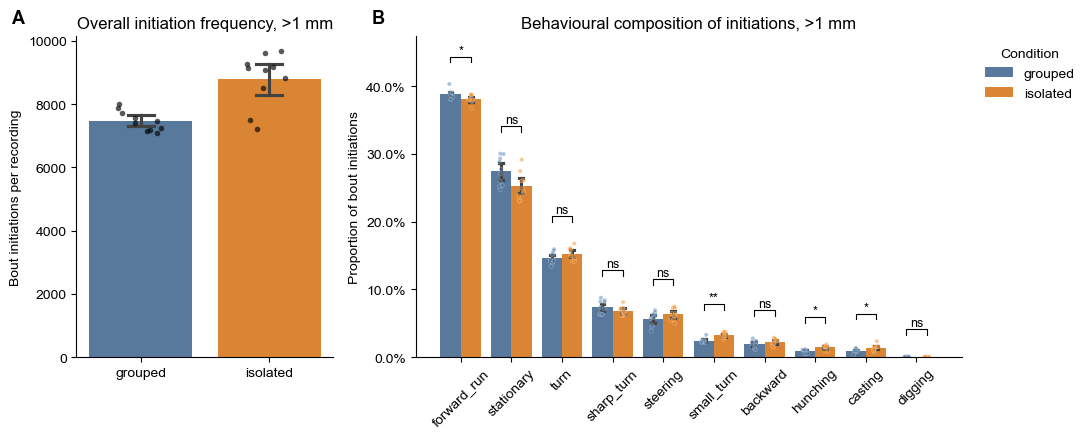

,condition,behaviour,mean_proportion,sem_proportion,mean_n_bouts,n_recordings,test,p_value,q_value_bh,significance
0,grouped,backward,0.019279,0.001731,143.1,10,Mann-Whitney U,0.161972,0.231389,ns
1,isolated,backward,0.022240,0.001433,195.5,10,Mann-Whitney U,0.161972,0.231389,ns
2,grouped,casting,0.009257,0.000918,68.9,10,Mann-Whitney U,0.011330,0.035048,*
3,isolated,casting,0.014081,0.001361,123.1,10,Mann-Whitney U,0.011330,0.035048,*
4,grouped,digging,0.000342,0.000137,2.6,10,Mann-Whitney U,0.334317,0.334317,ns
5,isolated,digging,0.000176,0.000068,1.4,10,Mann-Whitney U,0.334317,0.334317,ns
6,grouped,forward_run,0.387833,0.002100,2897.4,10,Mann-Whitney U,0.014019,0.035048,*
7,isolated,forward_run,0.380567,0.001893,3348.9,10,Mann-Whitney U,0.014019,0.035048,*
8,grouped,hunching,0.008609,0.000715,64.3,10,Mann-Whitney U,0.003611,0.018053,*
9,isolated,hunching,0.014609,0.001026,129.2,10,Mann-Whitney U,0.003611,0.018053,*


In [45]:
# Paper-style summary of bout initiations
# This first filters to frames where closest_node_node_distance is >1 mm, then shows:
# 1) total bout initiations per recording, and 2) the proportion of initiations assigned to each behaviour.
# Panel B also tests grouped vs isolated for each behaviour using per-recording proportions.

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

df_above_1mm = df[
    df["closest_node_node_distance"].notna()
    & (df["closest_node_node_distance"] > 1)
].copy()

df_above_1mm = df_above_1mm.sort_values(["file", "track_id", "frame"])

df_above_1mm["prev_behaviour"] = (
    df_above_1mm.groupby(["file", "track_id"])["behaviour"].shift()
)

df_above_1mm["is_initiation"] = (
    df_above_1mm["prev_behaviour"].notna()
    & (df_above_1mm["behaviour"] != df_above_1mm["prev_behaviour"])
)

bout_counts_above_1mm = (
    df_above_1mm[df_above_1mm["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

comparison_conditions = [c for c in ["grouped", "isolated"] if c in bout_counts_above_1mm["condition"].unique()]
if len(comparison_conditions) < 2:
    comparison_conditions = sorted(bout_counts_above_1mm["condition"].dropna().unique())

bout_counts_paper = bout_counts_above_1mm[bout_counts_above_1mm["condition"].isin(comparison_conditions)].copy()

behaviour_order = (
    bout_counts_paper.groupby("behaviour")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

file_condition = bout_counts_paper[["file", "condition"]].drop_duplicates()
behaviour_grid = pd.DataFrame({"behaviour": behaviour_order})

bout_counts_complete = (
    file_condition.assign(_key=1)
    .merge(behaviour_grid.assign(_key=1), on="_key")
    .drop(columns="_key")
    .merge(bout_counts_paper, on=["file", "condition", "behaviour"], how="left")
)

bout_counts_complete["n_bouts"] = bout_counts_complete["n_bouts"].fillna(0)

file_totals = (
    bout_counts_complete.groupby(["file", "condition"], as_index=False)["n_bouts"]
    .sum()
    .rename(columns={"n_bouts": "total_bout_initiations"})
)

bout_counts_complete = bout_counts_complete.merge(file_totals, on=["file", "condition"], how="left")
bout_counts_complete["bout_proportion"] = np.where(
    bout_counts_complete["total_bout_initiations"] > 0,
    bout_counts_complete["n_bouts"] / bout_counts_complete["total_bout_initiations"],
    np.nan,
)

def bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    valid = ~np.isnan(p_values)
    p_valid = p_values[valid]
    if len(p_valid) == 0:
        return adjusted

    order = np.argsort(p_valid)
    ranked = p_valid[order]
    n_tests = len(ranked)
    adjusted_ranked = ranked * n_tests / np.arange(1, n_tests + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)

    valid_indices = np.where(valid)[0]
    adjusted[valid_indices[order]] = adjusted_ranked
    return adjusted

def significance_label(q_value):
    if pd.isna(q_value):
        return "n/a"
    if q_value < 0.001:
        return "***"
    if q_value < 0.01:
        return "**"
    if q_value < 0.05:
        return "*"
    return "ns"

stats_rows = []
if len(comparison_conditions) == 2:
    condition_a, condition_b = comparison_conditions
    for behaviour in behaviour_order:
        values_a = bout_counts_complete.loc[
            (bout_counts_complete["condition"] == condition_a)
            & (bout_counts_complete["behaviour"] == behaviour),
            "bout_proportion",
        ].dropna()
        values_b = bout_counts_complete.loc[
            (bout_counts_complete["condition"] == condition_b)
            & (bout_counts_complete["behaviour"] == behaviour),
            "bout_proportion",
        ].dropna()

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            "test": "Mann-Whitney U",
            "p_value": p_value,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
        })

stats_table = pd.DataFrame(stats_rows)
if not stats_table.empty:
    stats_table["q_value_bh"] = bh_adjust(stats_table["p_value"])
    stats_table["significance"] = stats_table["q_value_bh"].apply(significance_label)

palette = {"grouped": "#4C78A8", "isolated": "#F58518"}
condition_palette = [palette.get(condition, "#6B6B6B") for condition in comparison_conditions]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    gridspec_kw={"width_ratios": [0.8, 1.7]},
)

sns.barplot(
    data=file_totals,
    x="condition",
    y="total_bout_initiations",
    order=comparison_conditions,
    palette=condition_palette,
    errorbar=("ci", 95),
    capsize=0.2,
    ax=axes[0],
)
sns.stripplot(
    data=file_totals,
    x="condition",
    y="total_bout_initiations",
    order=comparison_conditions,
    color="black",
    alpha=0.65,
    size=4,
    jitter=0.18,
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Bout initiations per recording")
axes[0].set_title("Overall initiation frequency, >1 mm")
axes[0].text(-0.25, 1.04, "A", transform=axes[0].transAxes, fontweight="bold", fontsize=13)

sns.barplot(
    data=bout_counts_complete,
    x="behaviour",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=comparison_conditions,
    palette=condition_palette,
    errorbar=("ci", 95),
    capsize=0.15,
    ax=axes[1],
)
sns.stripplot(
    data=bout_counts_complete,
    x="behaviour",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=comparison_conditions,
    palette=condition_palette,
    dodge=True,
    alpha=0.45,
    size=3,
    linewidth=0.3,
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Proportion of bout initiations")
axes[1].set_title("Behavioural composition of initiations, >1 mm")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis="x", rotation=45)
axes[1].text(-0.08, 1.04, "B", transform=axes[1].transAxes, fontweight="bold", fontsize=13)

if len(comparison_conditions) == 2 and not stats_table.empty:
    y_max = bout_counts_complete["bout_proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    axes[1].set_ylim(0, y_max + y_step * 2.2)

    for x_position, behaviour in enumerate(behaviour_order):
        q_value = stats_table.loc[stats_table["behaviour"] == behaviour, "q_value_bh"].iloc[0]
        label = significance_label(q_value)
        y = bout_counts_complete.loc[
            bout_counts_complete["behaviour"] == behaviour,
            "bout_proportion",
        ].max() + y_step
        x1, x2 = x_position - 0.2, x_position + 0.2
        axes[1].plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        axes[1].text(x_position, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles[:len(comparison_conditions)],
    labels[:len(comparison_conditions)],
    title="Condition",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

summary_table = (
    bout_counts_complete.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("bout_proportion", "mean"),
        sem_proportion=("bout_proportion", "sem"),
        mean_n_bouts=("n_bouts", "mean"),
        n_recordings=("file", "nunique"),
    )
    .sort_values(["behaviour", "condition"])
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "test", "p_value", "q_value_bh", "significance"]],
        on="behaviour",
        how="left",
    )

display(summary_table)

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_41025/3021820091.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


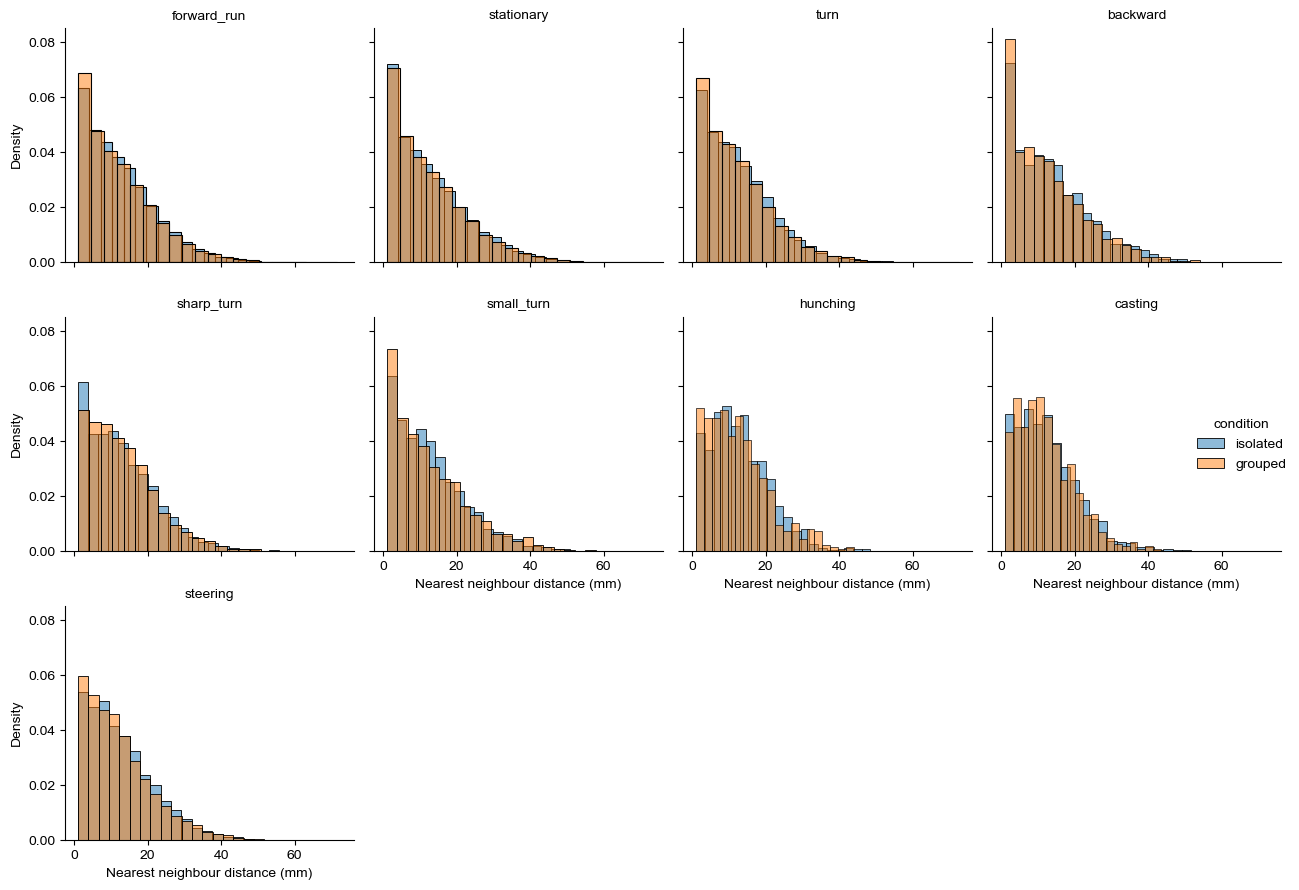

In [46]:


init_df = df[df["is_initiation"]].copy()
init_df = init_df[init_df["closest_node_node_distance"].notna()]
init_df = init_df[
    (init_df["closest_node_node_distance"].notna()) &
    (init_df["closest_node_node_distance"] >= 1)
]
init_df = init_df[init_df["behaviour"] != "digging"]  # optional

g = sns.FacetGrid(
    init_df,
    col="behaviour",
    col_wrap=4,
    hue="condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="closest_node_node_distance",
    bins=20,
    stat="density",     # so shapes comparable
    common_norm=False,  # IMPORTANT for hue comparison
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()



/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_41025/3471907387.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


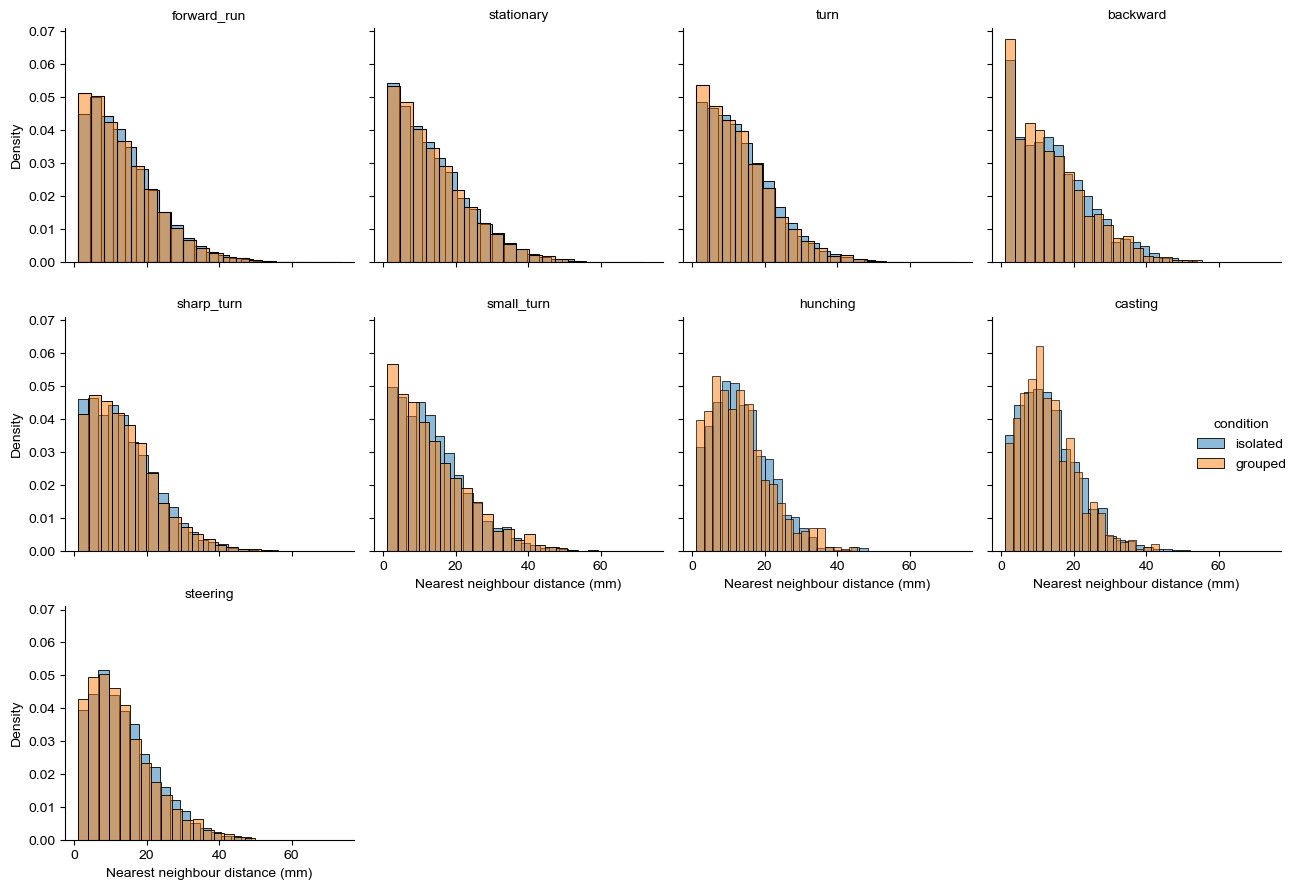

In [47]:

init_df = df[df["is_initiation"]].copy()
init_df = init_df[init_df["closest_node_node_distance"].notna()]
init_df = init_df[
    (init_df["closest_node_node_distance"].notna()) &
    (init_df["closest_node_node_distance"] >= 1)
]
init_df = init_df[init_df["behaviour"] != "digging"]  # optional

g = sns.FacetGrid(
    init_df,
    col="behaviour",
    col_wrap=4,
    hue="condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="head_distance",
    bins=20,
    stat="density",     # so shapes comparable
    common_norm=False,  # IMPORTANT for hue comparison
    alpha=0.5
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

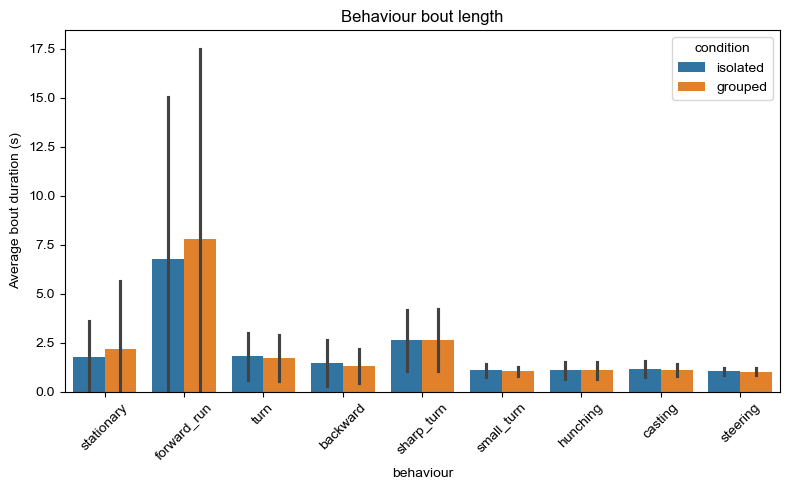

In [48]:
df["new_bout"] = df["behaviour"] != df["prev_behaviour"]

df["bout_id"] = df.groupby(["file", "track_id"])["new_bout"].cumsum()

bouts = (
    df.groupby(["file", "condition", "track_id", "bout_id", "behaviour"])
    .agg(
        start_frame=("frame", "min"),
        end_frame=("frame", "max"),
        n_frames=("frame", "count")
    )
    .reset_index()
)

bouts_no_digging = bouts[bouts["behaviour"] != "digging"].copy()

plt.figure(figsize=(8,5))

sns.barplot(
    data=bouts_no_digging,
    x="behaviour",
    y="n_frames",
    hue="condition",
    errorbar="sd"
)

plt.ylim(0,None )
plt.xticks(rotation=45)
plt.ylabel("Average bout duration (s)")
plt.title("Behaviour bout length")

plt.tight_layout()
plt.show()

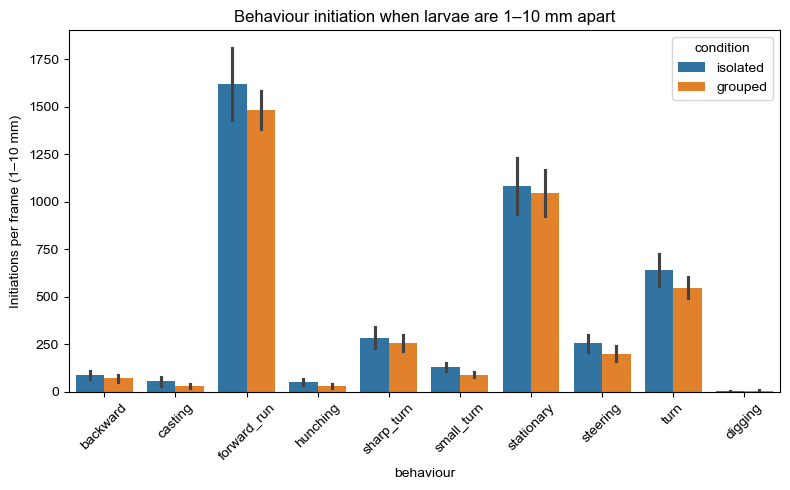

In [49]:
df_close = df[
    (df["closest_node_node_distance"].notna()) &
    (df["closest_node_node_distance"] >= 1) &
    (df["closest_node_node_distance"] <= 10)
].copy()

df_close = df_close.sort_values(["file", "track_id", "frame"])

df_close["prev_behaviour"] = (
    df_close.groupby(["file", "track_id"])["behaviour"].shift()
)

df_close["is_initiation"] = (
    df_close["prev_behaviour"].notna() &
    (df_close["behaviour"] != df_close["prev_behaviour"])
)

bout_counts = (
    df_close[df_close["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Initiations per frame (1–10 mm)")
plt.title("Behaviour initiation when larvae are 1–10 mm apart")

plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_41025/4038348096.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


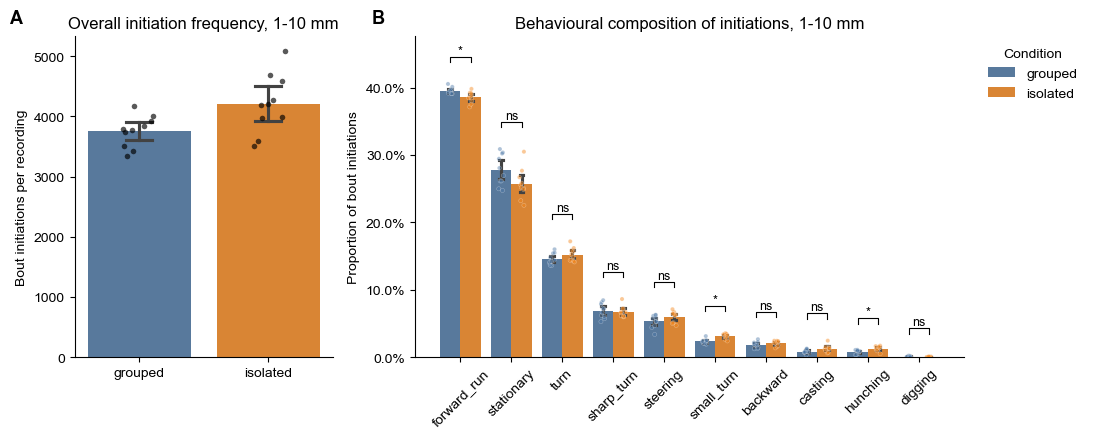

,condition,behaviour,mean_proportion,sem_proportion,mean_n_bouts,n_recordings,test,p_value,q_value_bh,significance
0,grouped,backward,0.018563,0.001416,69.6,10,Mann-Whitney U,0.307489,0.341655,ns
1,isolated,backward,0.020593,0.001159,87.4,10,Mann-Whitney U,0.307489,0.341655,ns
2,grouped,casting,0.008450,0.000886,31.6,10,Mann-Whitney U,0.037635,0.094088,ns
3,isolated,casting,0.012878,0.001599,54.2,10,Mann-Whitney U,0.037635,0.094088,ns
4,grouped,digging,0.000660,0.000257,2.5,10,Mann-Whitney U,0.297091,0.341655,ns
5,isolated,digging,0.000326,0.000127,1.3,10,Mann-Whitney U,0.297091,0.341655,ns
6,grouped,forward_run,0.395299,0.001535,1483.7,10,Mann-Whitney U,0.009108,0.030362,*
7,isolated,forward_run,0.385403,0.002578,1621.2,10,Mann-Whitney U,0.009108,0.030362,*
8,grouped,hunching,0.007785,0.000864,29.1,10,Mann-Whitney U,0.004586,0.022932,*
9,isolated,hunching,0.012733,0.001135,53.1,10,Mann-Whitney U,0.004586,0.022932,*


In [50]:
# Paper-style summary of close-range bout initiations
# Same analysis style as above, but restricted to frames where larvae are >1 and <=10 mm apart.
# Panel B tests grouped vs isolated for each behaviour using per-recording proportions.

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

comparison_conditions = [c for c in ["grouped", "isolated"] if c in bout_counts["condition"].unique()]
if len(comparison_conditions) < 2:
    comparison_conditions = sorted(bout_counts["condition"].dropna().unique())

bout_counts_close_paper = bout_counts[bout_counts["condition"].isin(comparison_conditions)].copy()

behaviour_order = (
    bout_counts_close_paper.groupby("behaviour")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

file_condition = bout_counts_close_paper[["file", "condition"]].drop_duplicates()
behaviour_grid = pd.DataFrame({"behaviour": behaviour_order})

bout_counts_close_complete = (
    file_condition.assign(_key=1)
    .merge(behaviour_grid.assign(_key=1), on="_key")
    .drop(columns="_key")
    .merge(bout_counts_close_paper, on=["file", "condition", "behaviour"], how="left")
)

bout_counts_close_complete["n_bouts"] = bout_counts_close_complete["n_bouts"].fillna(0)

file_totals_close = (
    bout_counts_close_complete.groupby(["file", "condition"], as_index=False)["n_bouts"]
    .sum()
    .rename(columns={"n_bouts": "total_bout_initiations"})
)

bout_counts_close_complete = bout_counts_close_complete.merge(file_totals_close, on=["file", "condition"], how="left")
bout_counts_close_complete["bout_proportion"] = np.where(
    bout_counts_close_complete["total_bout_initiations"] > 0,
    bout_counts_close_complete["n_bouts"] / bout_counts_close_complete["total_bout_initiations"],
    np.nan,
)

def bh_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)
    valid = ~np.isnan(p_values)
    p_valid = p_values[valid]
    if len(p_valid) == 0:
        return adjusted

    order = np.argsort(p_valid)
    ranked = p_valid[order]
    n_tests = len(ranked)
    adjusted_ranked = ranked * n_tests / np.arange(1, n_tests + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)

    valid_indices = np.where(valid)[0]
    adjusted[valid_indices[order]] = adjusted_ranked
    return adjusted

def significance_label(q_value):
    if pd.isna(q_value):
        return "n/a"
    if q_value < 0.001:
        return "***"
    if q_value < 0.01:
        return "**"
    if q_value < 0.05:
        return "*"
    return "ns"

stats_rows = []
if len(comparison_conditions) == 2:
    condition_a, condition_b = comparison_conditions
    for behaviour in behaviour_order:
        values_a = bout_counts_close_complete.loc[
            (bout_counts_close_complete["condition"] == condition_a)
            & (bout_counts_close_complete["behaviour"] == behaviour),
            "bout_proportion",
        ].dropna()
        values_b = bout_counts_close_complete.loc[
            (bout_counts_close_complete["condition"] == condition_b)
            & (bout_counts_close_complete["behaviour"] == behaviour),
            "bout_proportion",
        ].dropna()

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            "test": "Mann-Whitney U",
            "p_value": p_value,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
        })

stats_table_close = pd.DataFrame(stats_rows)
if not stats_table_close.empty:
    stats_table_close["q_value_bh"] = bh_adjust(stats_table_close["p_value"])
    stats_table_close["significance"] = stats_table_close["q_value_bh"].apply(significance_label)

palette = {"grouped": "#4C78A8", "isolated": "#F58518"}
condition_palette = [palette.get(condition, "#6B6B6B") for condition in comparison_conditions]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    gridspec_kw={"width_ratios": [0.8, 1.7]},
)

sns.barplot(
    data=file_totals_close,
    x="condition",
    y="total_bout_initiations",
    order=comparison_conditions,
    palette=condition_palette,
    errorbar=("ci", 95),
    capsize=0.2,
    ax=axes[0],
)
sns.stripplot(
    data=file_totals_close,
    x="condition",
    y="total_bout_initiations",
    order=comparison_conditions,
    color="black",
    alpha=0.65,
    size=4,
    jitter=0.18,
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Bout initiations per recording")
axes[0].set_title("Overall initiation frequency, 1-10 mm")
axes[0].text(-0.25, 1.04, "A", transform=axes[0].transAxes, fontweight="bold", fontsize=13)

sns.barplot(
    data=bout_counts_close_complete,
    x="behaviour",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=comparison_conditions,
    palette=condition_palette,
    errorbar=("ci", 95),
    capsize=0.15,
    ax=axes[1],
)
sns.stripplot(
    data=bout_counts_close_complete,
    x="behaviour",
    y="bout_proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=comparison_conditions,
    palette=condition_palette,
    dodge=True,
    alpha=0.45,
    size=3,
    linewidth=0.3,
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Proportion of bout initiations")
axes[1].set_title("Behavioural composition of initiations, 1-10 mm")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].tick_params(axis="x", rotation=45)
axes[1].text(-0.08, 1.04, "B", transform=axes[1].transAxes, fontweight="bold", fontsize=13)

if len(comparison_conditions) == 2 and not stats_table_close.empty:
    y_max = bout_counts_close_complete["bout_proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    axes[1].set_ylim(0, y_max + y_step * 2.2)

    for x_position, behaviour in enumerate(behaviour_order):
        q_value = stats_table_close.loc[stats_table_close["behaviour"] == behaviour, "q_value_bh"].iloc[0]
        label = significance_label(q_value)
        y = bout_counts_close_complete.loc[
            bout_counts_close_complete["behaviour"] == behaviour,
            "bout_proportion",
        ].max() + y_step
        x1, x2 = x_position - 0.2, x_position + 0.2
        axes[1].plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        axes[1].text(x_position, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles[:len(comparison_conditions)],
    labels[:len(comparison_conditions)],
    title="Condition",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

summary_table_close = (
    bout_counts_close_complete.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("bout_proportion", "mean"),
        sem_proportion=("bout_proportion", "sem"),
        mean_n_bouts=("n_bouts", "mean"),
        n_recordings=("file", "nunique"),
    )
    .sort_values(["behaviour", "condition"])
)

if not stats_table_close.empty:
    summary_table_close = summary_table_close.merge(
        stats_table_close[["behaviour", "test", "p_value", "q_value_bh", "significance"]],
        on="behaviour",
        how="left",
    )

display(summary_table_close)

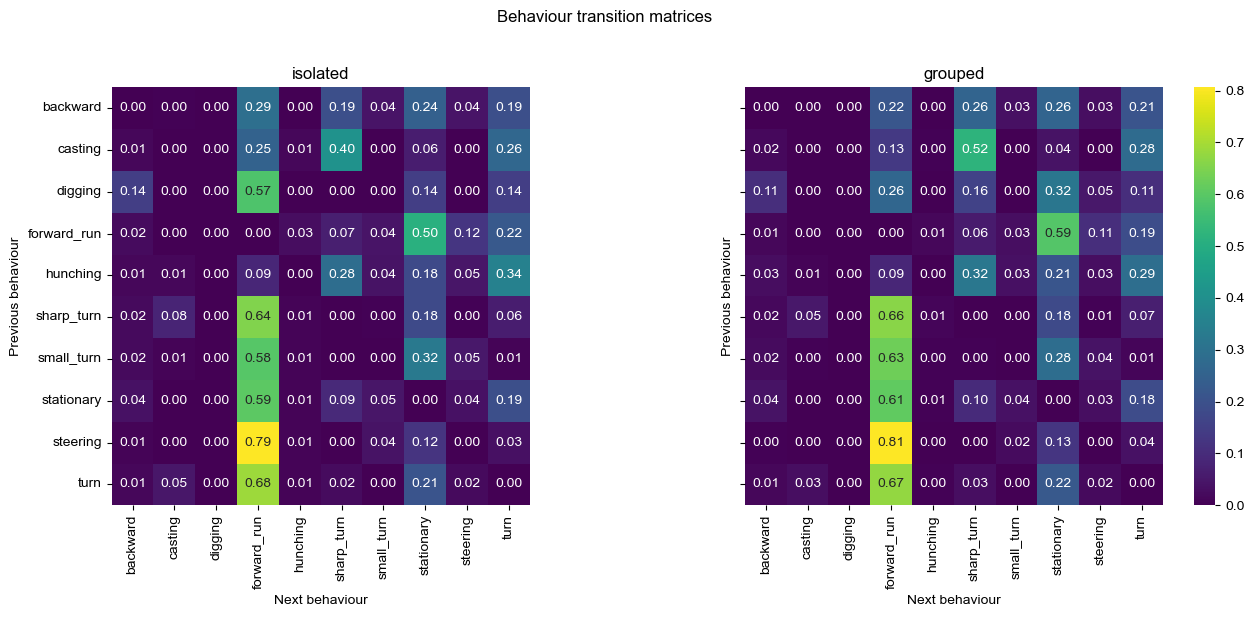

In [51]:
df_trans = df.sort_values(["file", "track_id", "frame"]).copy()

df_trans["prev_behaviour"] = (
    df_trans.groupby(["file", "track_id"])["behaviour"].shift()
)

df_trans = df_trans[
    df_trans["prev_behaviour"].notna() &
    (df_trans["behaviour"] != df_trans["prev_behaviour"])
].copy()

conditions = ["isolated", "grouped"]  # enforce order

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, condition in zip(axes, conditions):

    mat = pd.crosstab(
        df_trans.loc[df_trans["condition"] == condition, "prev_behaviour"],
        df_trans.loc[df_trans["condition"] == condition, "behaviour"],
        normalize="index"
    )

    sns.heatmap(
        mat,
        ax=ax,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar=ax == axes[-1],  # only show one colorbar
        square=True
    )

    ax.set_title(condition)
    ax.set_xlabel("Next behaviour")
    ax.set_ylabel("Previous behaviour")

plt.suptitle("Behaviour transition matrices", y=1.02)
plt.tight_layout()
plt.show()

mb only within 5mm and facing other larvae idk?

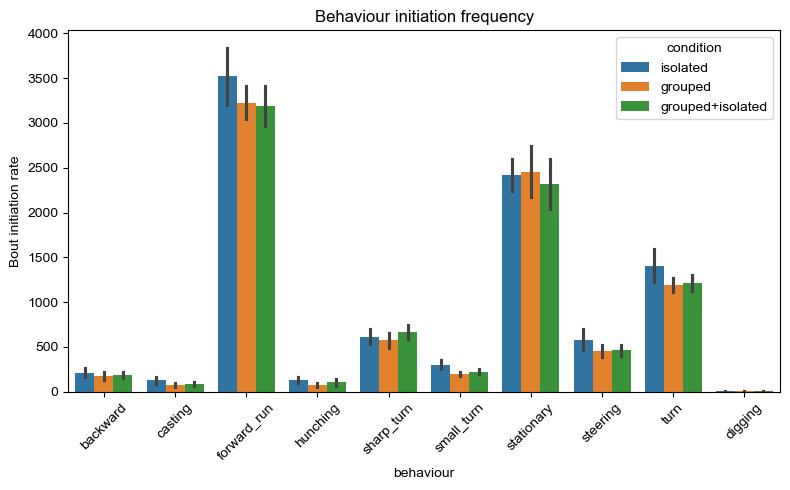

In [52]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'grouped'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'isolated'

df_ghsi = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/behaviour_detection.csv")
df_ghsi["condition"] = 'grouped+isolated'

df = pd.concat([df1, df2, df_ghsi], ignore_index=True)


df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()





/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_41025/3907876656.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


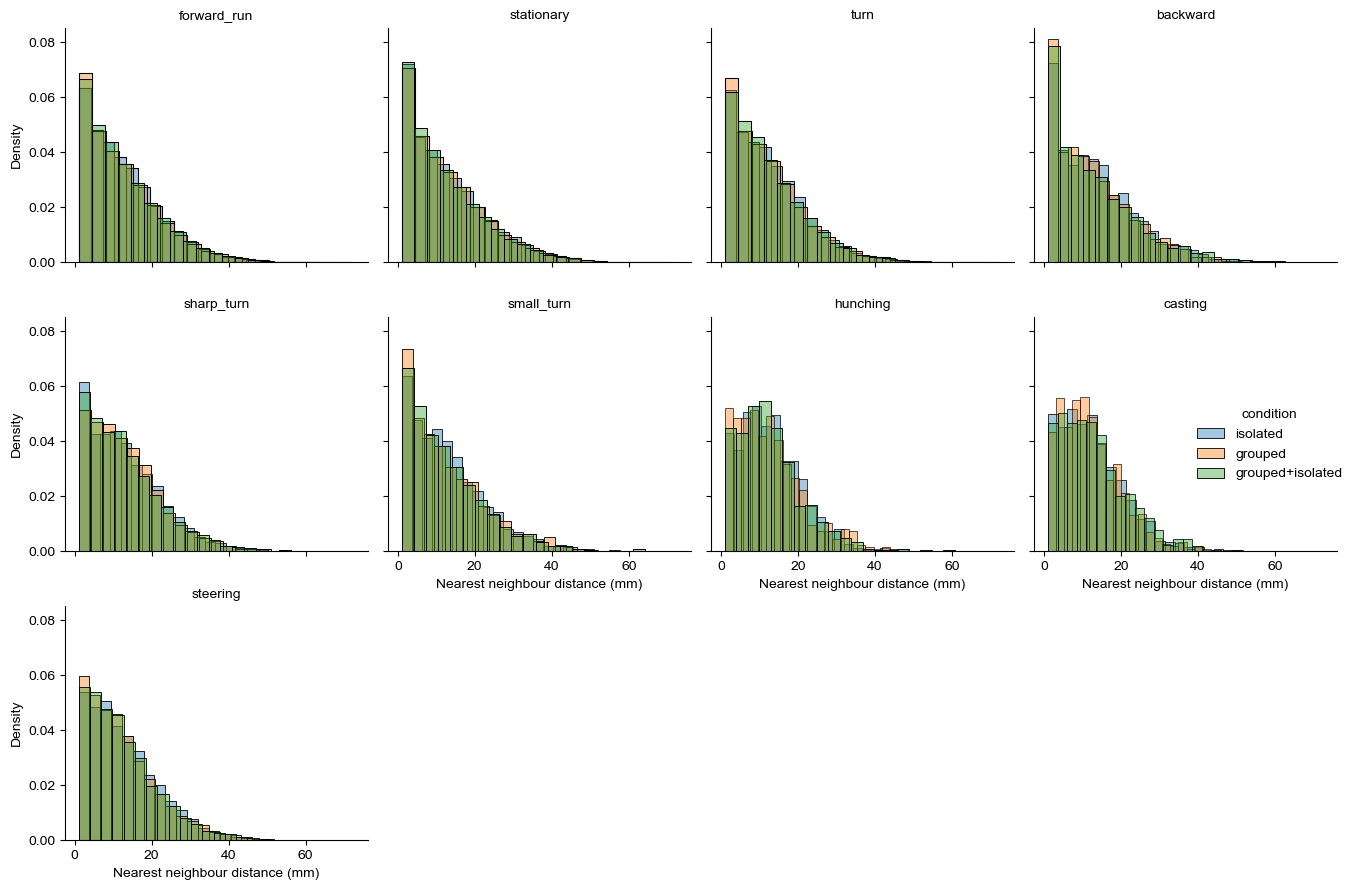

In [53]:
init_df = df[df["is_initiation"]].copy()
init_df = init_df[init_df["closest_node_node_distance"].notna()]
init_df = init_df[
    (init_df["closest_node_node_distance"].notna()) &
    (init_df["closest_node_node_distance"] >= 1)
]
init_df = init_df[init_df["behaviour"] != "digging"]  # optional

g = sns.FacetGrid(
    init_df,
    col="behaviour",
    col_wrap=4,
    hue="condition",
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="closest_node_node_distance",
    bins=20,
    stat="density",     # so shapes comparable
    common_norm=False,  # IMPORTANT for hue comparison
    alpha=0.4
)

g.add_legend()

g.set_axis_labels("Nearest neighbour distance (mm)", "Density")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()

In [54]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/behaviour_detection.csv")

df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

df["social_experience"] = np.where(
    df["track_id"].between(0, 4),
    "iso",
    np.where(df["track_id"].between(5, 9), "group", np.nan)
)



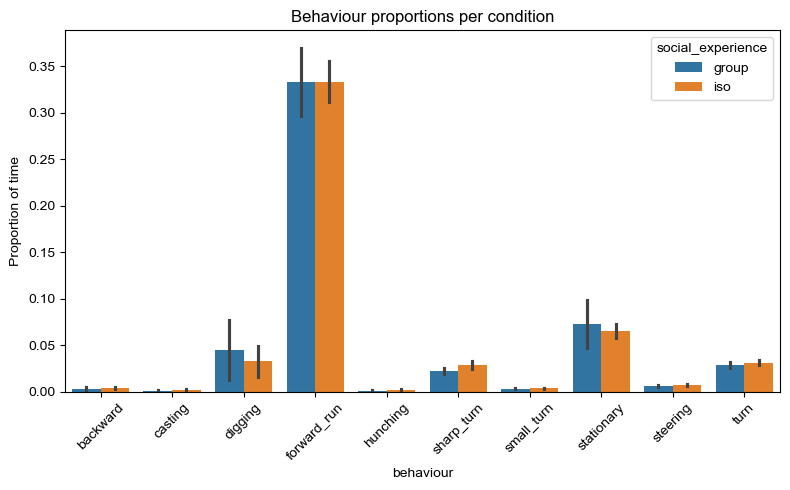

In [55]:
# total frames per video
total_frames = (
    df.groupby(["file"])
    .size()
    .reset_index(name="total_frames")
)

# frames per behaviour per video
behaviour_frames = (
    df.groupby(["file", "social_experience", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# merge + compute proportion
behaviour_prop = behaviour_frames.merge(total_frames, on="file")
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]


plt.figure(figsize=(8,5))

sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="social_experience",
    errorbar="sd"
)

plt.ylim(0,None)
plt.xticks(rotation=45)
plt.ylabel("Proportion of time")
plt.title("Behaviour proportions per condition")

plt.tight_layout()
plt.show()

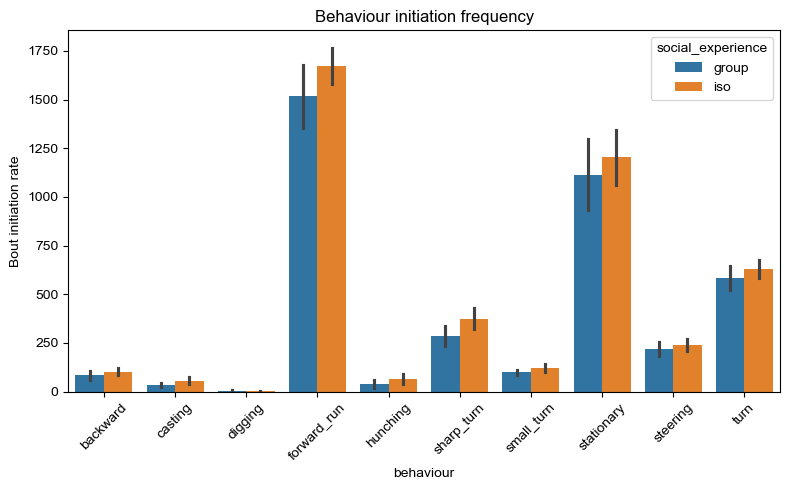

In [56]:
bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "social_experience", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="social_experience",
    errorbar="sd"
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()

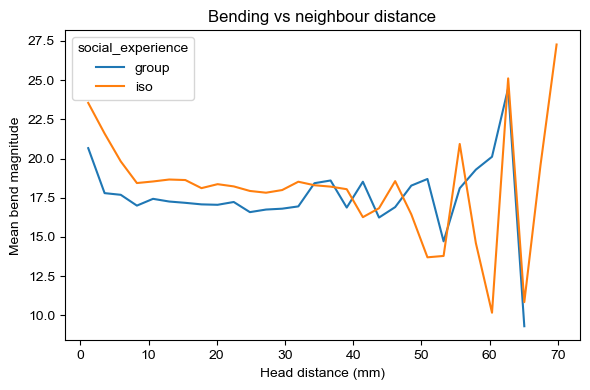

In [57]:
df_plot = df[
    (df["head_distance"].notna()) &
    (df["bend_magnitude"].notna())
].copy()

# bin distances
df_plot["distance_bin"] = pd.cut(df_plot["head_distance"], bins=30)

# get bin centres
df_plot["distance_mid"] = df_plot["distance_bin"].apply(lambda x: x.mid)

binned = (
    df_plot.groupby(["distance_mid", "social_experience"])["bend_magnitude"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.lineplot(
    data=binned,
    x="distance_mid",
    y="bend_magnitude",
    hue="social_experience"
)

plt.ylabel("Mean bend magnitude")
plt.xlabel("Head distance (mm)")
plt.title("Bending vs neighbour distance")

plt.tight_layout()
plt.show()

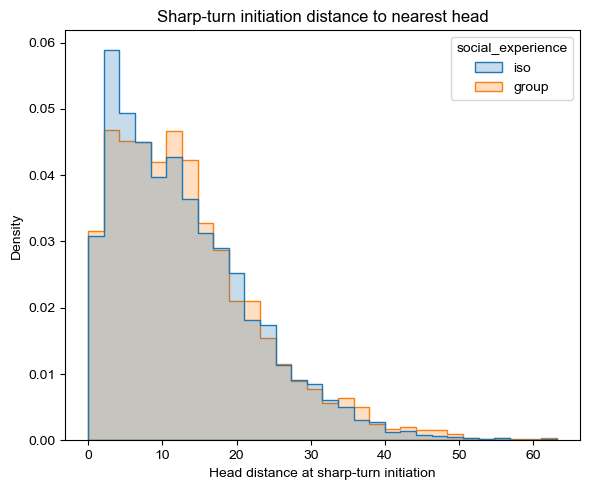

In [58]:
df = df[df["prev_behaviour"].notna()].copy()

# Keep only sharp turn initiation frames
sharp_turn_init = df[
    (df["is_initiation"]) &
    (df["behaviour"] == "sharp_turn")
].copy()

plt.figure(figsize=(6, 5))

sns.histplot(
    data=sharp_turn_init,
    x="head_distance",
    hue="social_experience",
    element="step",
    stat="density",
    common_norm=False,
    bins=30
)

plt.xlabel("Head distance at sharp-turn initiation")
plt.ylabel("Density")
plt.title("Sharp-turn initiation distance to nearest head")
plt.tight_layout()
plt.show()

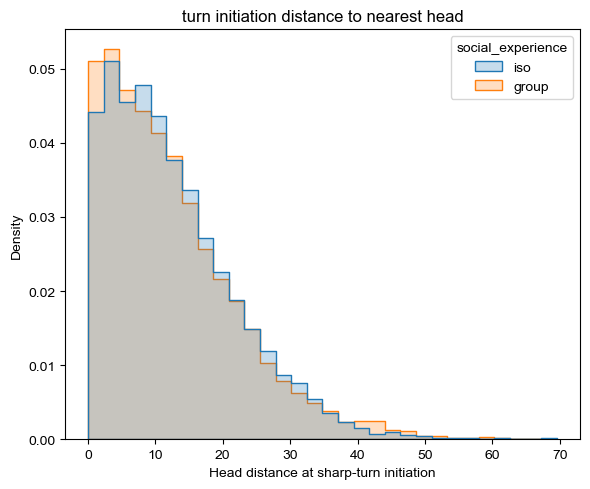

In [59]:
df = df[df["prev_behaviour"].notna()].copy()

# Keep only sharp turn initiation frames
sharp_turn_init = df[
    (df["is_initiation"]) &
    (df["behaviour"] == "turn")
].copy()

plt.figure(figsize=(6, 5))

sns.histplot(
    data=sharp_turn_init,
    x="head_distance",
    hue="social_experience",
    element="step",
    stat="density",
    common_norm=False,
    bins=30
)

plt.xlabel("Head distance at sharp-turn initiation")
plt.ylabel("Density")
plt.title("turn initiation distance to nearest head")
plt.tight_layout()
plt.show()